In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt


In [2]:
base = "/content/drive/MyDrive/milano_project/results/"

# offload = torch.tensor(np.loadtxt(base + "offloading_decisions.txt"))
CL = torch.tensor(np.loadtxt(base + "edge_cost.txt"))
CR = torch.tensor(np.loadtxt(base + "cloud_cost.txt"))

lambda_rtt = 0.02
RTT_cloud = 30   # choose experiment value

CR_eff = CR + lambda_rtt * RTT_cloud
offload = (CL > CR_eff).int()


len(offload), len(CL), len(CR)


(1002, 1002, 1002)

In [3]:
cost_edge_only = CL.mean().item()
cost_edge_only


4.867286526038499

In [4]:
cost_cloud_only = CR.mean().item()
cost_cloud_only


3.1131696416708285

In [5]:
offload_rate = offload.float().mean().item()

random_offload = (torch.rand(len(offload)) < offload_rate).int()

cost_random = (
    random_offload * CR + (1 - random_offload) * CL
).mean().item()

cost_random


3.1415330114478834

In [6]:
cost_optimized = (
    offload * CR + (1 - offload) * CL
).mean().item()

cost_optimized


3.117748911628228

In [7]:
print("Average SLA Cost Comparison")
print("----------------------------")
print(f"Edge-only      : {cost_edge_only:.3f}")
print(f"Cloud-only     : {cost_cloud_only:.3f}")
print(f"Random offload : {cost_random:.3f}")
print(f"Optimized offl : {cost_optimized:.3f}")


Average SLA Cost Comparison
----------------------------
Edge-only      : 4.867
Cloud-only     : 3.113
Random offload : 3.142
Optimized offl : 3.118


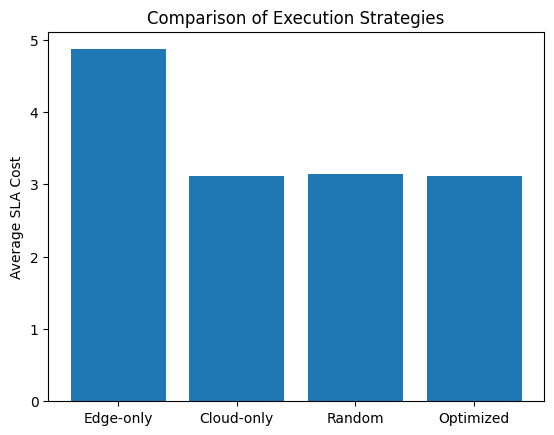

In [8]:
labels = ["Edge-only", "Cloud-only", "Random", "Optimized"]
costs = [
    cost_edge_only,
    cost_cloud_only,
    cost_random,
    cost_optimized
]

plt.bar(labels, costs)
plt.ylabel("Average SLA Cost")
plt.title("Comparison of Execution Strategies")
plt.show()


In [9]:
print(f"Optimized offloading rate: {offload_rate*100:.2f}%")


Optimized offloading rate: 98.40%


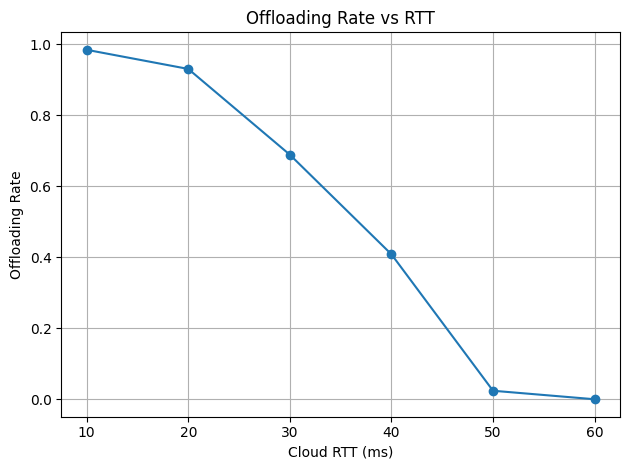

In [10]:
import matplotlib.pyplot as plt

RTT_values = [10, 20, 30, 40, 50, 60]
lambda_rtt = 0.05  # same value you used

offload_rates = []

for rtt in RTT_values:
    CR_eff = CR + lambda_rtt * rtt
    offload = (CL > CR_eff).int()
    rate = offload.float().mean().item()
    offload_rates.append(rate)

plt.figure()
plt.plot(RTT_values, offload_rates, marker='o')
plt.xlabel("Cloud RTT (ms)")
plt.ylabel("Offloading Rate")
plt.title("Offloading Rate vs RTT")
plt.grid(True)
plt.tight_layout()
plt.show()


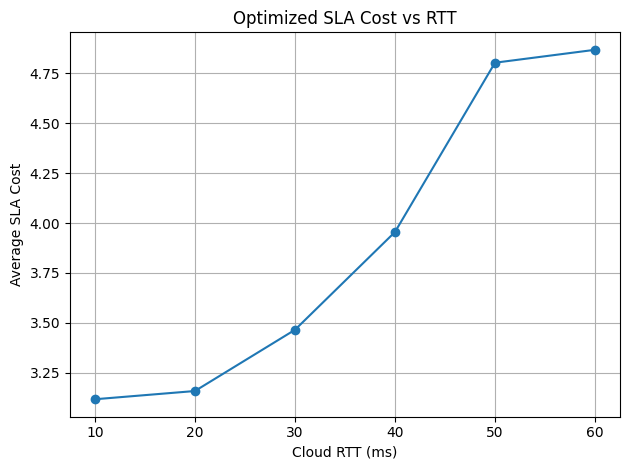

In [11]:
optimized_costs = []

for rtt in RTT_values:
    CR_eff = CR + lambda_rtt * rtt
    offload = (CL > CR_eff).int()

    # If offload = 1 → use CR, else CL
    final_cost = offload * CR + (1 - offload) * CL
    optimized_costs.append(final_cost.mean().item())

plt.figure()
plt.plot(RTT_values, optimized_costs, marker='o')
plt.xlabel("Cloud RTT (ms)")
plt.ylabel("Average SLA Cost")
plt.title("Optimized SLA Cost vs RTT")
plt.grid(True)
plt.tight_layout()
plt.show()


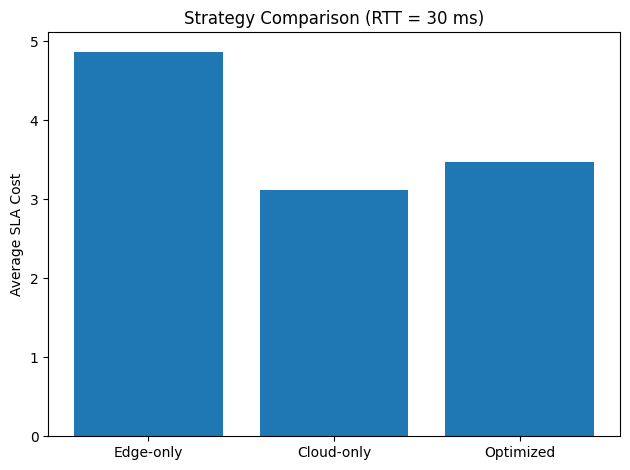

In [12]:
rtt_test = 30
CR_eff = CR + lambda_rtt * rtt_test
offload = (CL > CR_eff).int()

optimized_cost = (offload * CR + (1 - offload) * CL).mean().item()
edge_cost = CL.mean().item()
cloud_cost = CR.mean().item()

strategies = ["Edge-only", "Cloud-only", "Optimized"]
values = [edge_cost, cloud_cost, optimized_cost]

plt.figure()
plt.bar(strategies, values)
plt.ylabel("Average SLA Cost")
plt.title(f"Strategy Comparison (RTT = {rtt_test} ms)")
plt.tight_layout()
plt.show()


In [13]:
#sensitivity analysis                                 ignore this section,,,this i did before fintuning hyperparameters and adjusting hard slas and RTT

In [14]:
def soften_cost(C, eps=0.2):
    """
    Soften saturated SLA cost for sensitivity analysis ONLY.
    """
    return C - eps * torch.rand_like(C)


In [15]:
CL_soft = soften_cost(CL)
CR_soft = soften_cost(CR)


In [16]:
cost_edge_only_soft = CL_soft.mean().item()
cost_cloud_only_soft = CR_soft.mean().item()

cost_random_soft = (
    random_offload * CR_soft + (1 - random_offload) * CL_soft
).mean().item()

cost_optimized_soft = (
    offload * CR_soft + (1 - offload) * CL_soft
).mean().item()


In [17]:
print("Sensitivity Analysis (Softened SLA Cost)")
print("--------------------------------------")
print(f"Edge-only      : {cost_edge_only_soft:.3f}")
print(f"Cloud-only     : {cost_cloud_only_soft:.3f}")
print(f"Random offload : {cost_random_soft:.3f}")
print(f"Optimized offl : {cost_optimized_soft:.3f}")


Sensitivity Analysis (Softened SLA Cost)
--------------------------------------
Edge-only      : 4.765
Cloud-only     : 3.012
Random offload : 3.041
Optimized offl : 3.367


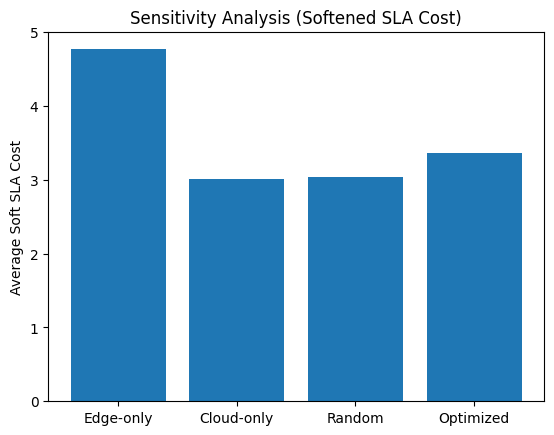

In [18]:
labels = ["Edge-only", "Cloud-only", "Random", "Optimized"]
costs = [
    cost_edge_only_soft,
    cost_cloud_only_soft,
    cost_random_soft,
    cost_optimized_soft
]

plt.bar(labels, costs)
plt.ylabel("Average Soft SLA Cost")
plt.title("Sensitivity Analysis (Softened SLA Cost)")
plt.show()


In [19]:
print(f"Optimized offloading rate: {offload.float().mean().item() * 100:.2f}%")


Optimized offloading rate: 68.86%


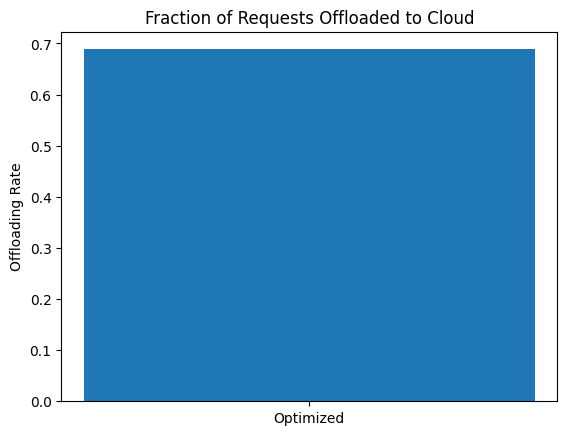

In [20]:
plt.bar(["Optimized"], [offload.float().mean().item()])
plt.ylabel("Offloading Rate")
plt.title("Fraction of Requests Offloaded to Cloud")
plt.show()


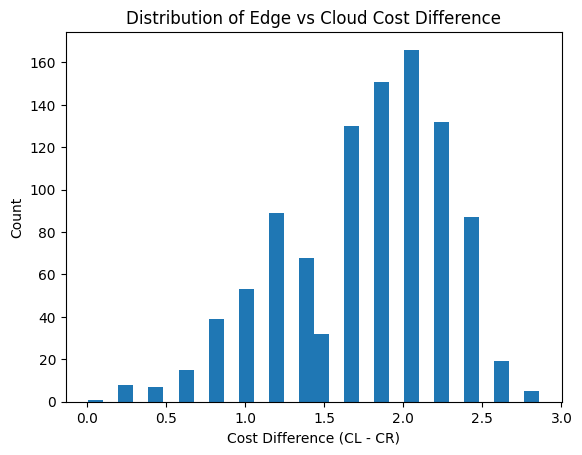

In [21]:
plt.hist((CL - CR).numpy(), bins=30)
plt.xlabel("Cost Difference (CL - CR)")
plt.ylabel("Count")
plt.title("Distribution of Edge vs Cloud Cost Difference")
plt.show()
